In [2]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:

def plot_market_demand_forecast(
    n_history: int = 30,
    n_forecast: int = 20,
    seed: int = 42,
) -> None:
    """
    Plot historical market demand with a forecast confidence interval.

    Parameters
    ----------
    n_history : int
        Number of historical time steps.
    n_forecast : int
        Number of forecast time steps.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    None
        Displays the matplotlib figure.
    """
    rng = np.random.default_rng(seed)

    # --- time axis ---
    time_history = np.arange(n_history)
    time_forecast = np.arange(n_history, n_history + n_forecast)

    # --- historical demand (smooth upward trend + noise) ---
    demand_history = (
        50
        + 1.2 * time_history
        + rng.normal(0, 1.5, size=n_history)
    )

    # --- forecast mean continues last trend ---
    last_value = demand_history[-1]
    trend = 1.1
    demand_forecast_mean = last_value + trend * np.arange(1, n_forecast + 1)

    # --- confidence interval widens over time ---
    uncertainty = 3 + 0.25 * np.arange(1, n_forecast + 1)
    lower_bound = demand_forecast_mean - uncertainty
    upper_bound = demand_forecast_mean + uncertainty

    # --- plot ---
    fig, ax = plt.subplots(figsize=(10, 5))

    # historical line
    ax.plot(
        time_history,
        demand_history,
        linewidth=2.5,
        label="historical demand",
    )

    # confidence interval (forecast region)
    ax.fill_between(
        time_forecast,
        lower_bound,
        upper_bound,
        alpha=0.25,
        label="forecast confidence interval",
    )

    # vertical divider between history and forecast
    ax.axvline(
        x=n_history - 0.5,
        linestyle="--",
        linewidth=1,
        alpha=0.6,
    )

    # labels
    ax.set_xlabel("Time")
    ax.set_ylabel("Market demand")

    # clean aesthetics
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.2)

    ax.legend(frameon=False)
    plt.tight_layout()
    plt.show()


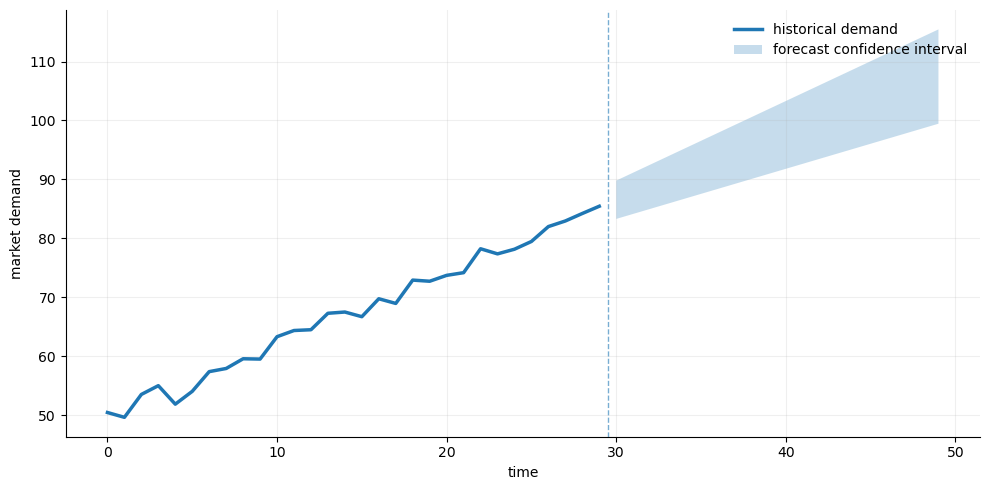

In [4]:
plot_market_demand_forecast()